### Import all packages need in the cell below

In [3]:
import Pkg
Pkg.add("JuMP")
Pkg.add("HiGHS")
Pkg.add("Ipopt")
Pkg.add("LinearAlgebra")

   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`
   Resolving package versions...
    Updating `~/.julia/environments/v1.12/Project.toml`
  [37e2e46d] + LinearAlgebra v1.12.0
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`


In [2]:
using JuMP
using HiGHS
using Plots
using Ipopt
using LinearAlgebra

[ Info: Precompiling IpoptMathOptInterfaceExt [9f03943f-3ac1-51ea-b4a2-58bda43ee6d1]
[ Info: Precompiling IpoptMathOptInterfaceExt [9f03943f-3ac1-51ea-b4a2-58bda43ee6d1] 

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


# Problem Statement

Plot the graph of the function sin(x) over the interval $[-\pi/4, 3\pi/4]$

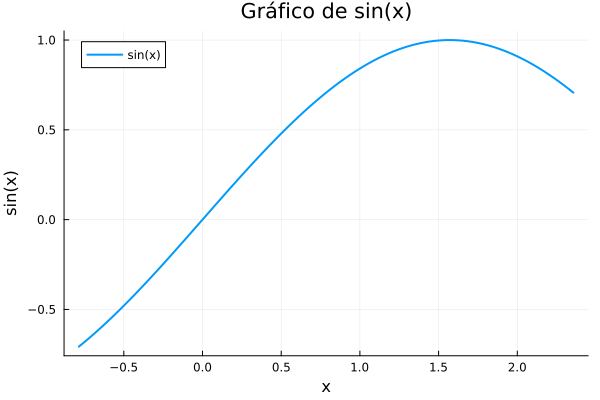

In [ ]:
x = range(-pi/4, 3pi/4, length=100)

# função
y = sin.(x)

# gráfico
plot(
    x,
    y,
    label="sin(x)",
    xlabel="x",
    ylabel="sin(x)",
    title="Gráfico de sin(x)",
    linewidth=2
)

Plot the graph of the function $x\cdot sin(x)$ over the interval $[-10\pi, 10\pi]$

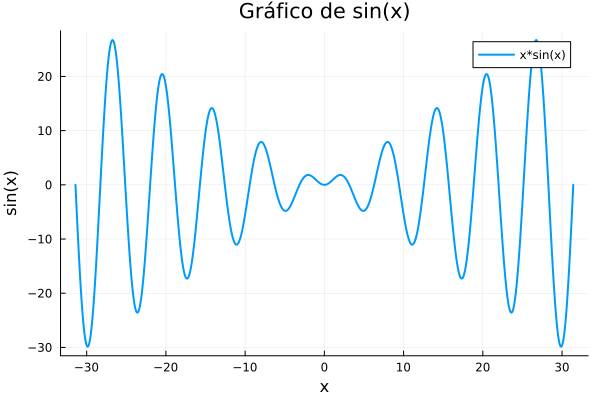

In [ ]:
x = range(-10pi, 10pi, length=1000)

# função
y = x.*sin.(x)

# gráfico
plot(
    x,
    y,
    label="x*sin(x)",
    xlabel="x",
    ylabel="sin(x)",
    title="Gráfico de sin(x)",
    linewidth=2
)

# Problem Statement

Solve the Cylinder Problem considering the following data:

* N: 10
* $c_1$: 2
* $c_2$: 0.5
  

In [ ]:
# Dados
N = 10
c1 = 2
c2 = 0.5

# Modelo
model = Model(Ipopt.Optimizer)

# Variáveis
@variable(model, r >= 0.0001)
@variable(model, h >= 0.0001)

# Função objetivo: minimizar custo
@NLobjective(model, Min, c1 * (2*pi*r^2) + c2 * (2*pi*r*h))

# Restrição de volume
@NLconstraint(model, pi*r^2*h == N)

# Resolver
optimize!(model)

println("Status: ", termination_status(model))
println("Raio ótimo r = ", value(r))
println("Altura ótima h = ", value(h))
println("Custo mínimo = ", objective_value(model))


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:        2
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        6

Total number of variables............................:        2
                     variables with only lower bounds:        2
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        1
Total number of inequality c

# Problem Statement

Solve the Awning Problem considering the following data:

* h: 2
* w: 3
* initial guess $(x,y) = (1.0, 1.0)$
  

In [ ]:
# Dados
h = 2
w = 3

# Modelo
model = Model(Ipopt.Optimizer)

# Variáveis positivas com chute inicial
@variable(model, x >= 0.0001, start = 1.0)
@variable(model, y >= 0.0001, start = 1.0)

# Função objetivo
@NLobjective(model, Min, sqrt(x^2 + y^2))

# Restrição
@NLconstraint(model, y - w * y / x >= h)

# Resolver
optimize!(model)

println("Status: ", termination_status(model))
println("x ótimo = ", value(x))
println("y ótimo = ", value(y))
println("z mínimo = ", objective_value(model))

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:        0
Number of nonzeros in inequality constraint Jacobian.:        2
Number of nonzeros in Lagrangian Hessian.............:        6

Total number of variables............................:        2
                     variables with only lower bounds:        2
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        0
Total number of inequality constraints...............:        1
        inequality constraints with only lower bounds:        1
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  1.4142136e+00 4.00e+00 9.49e-01  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

# Problem Statement

Solve the Packing Problem

In [ ]:
# code

# Problem Statement

Solve the 3-bus Optimal Power Flow Problem with following data:

![image.png](attachment:dea684d8-257b-4a4e-a3f9-f6993fad9896.png)

In [4]:
model = Model(Ipopt.Optimizer)

# -----------------------------
# Data
# -----------------------------

r = 0.01
x = 0.1

y = 1 / complex(r, x)
g = real(y)
b = imag(y)

println("Line admittance: g = ", g, ", b = ", b)

# Loads
Pd = [0.0, 0.0, 0.8]
Qd = [0.0, 0.0, 0.6]

# Cost
c1 = 2.0
c2 = 1.0

# Voltage bounds
vmin = 0.95
vmax = 1.10

# Line limits
smax12 = 0.25
smax13 = 2.0
smax23 = 2.0

# -----------------------------
# Variables
# -----------------------------

@variable(model, 0 <= p1 <= 3)
@variable(model, 0 <= p2 <= 0.8)

@variable(model, -2 <= q1 <= 2)
@variable(model, -2 <= q2 <= 2)

@variable(model, vmin <= v[1:3] <= vmax)
@variable(model, θ[1:3])

# Reference angle
@constraint(model, θ[3] == 0)

# -----------------------------
# Power flow expressions
# -----------------------------

@NLexpression(model, P12, g*v[1]^2 - v[1]*v[2]*(g*cos(θ[1]-θ[2]) + b*sin(θ[1]-θ[2])))
@NLexpression(model, Q12, -b*v[1]^2 - v[1]*v[2]*(g*sin(θ[1]-θ[2]) - b*cos(θ[1]-θ[2])))

@NLexpression(model, P21, g*v[2]^2 - v[2]*v[1]*(g*cos(θ[2]-θ[1]) + b*sin(θ[2]-θ[1])))
@NLexpression(model, Q21, -b*v[2]^2 - v[2]*v[1]*(g*sin(θ[2]-θ[1]) - b*cos(θ[2]-θ[1])))

@NLexpression(model, P13, g*v[1]^2 - v[1]*v[3]*(g*cos(θ[1]-θ[3]) + b*sin(θ[1]-θ[3])))
@NLexpression(model, Q13, -b*v[1]^2 - v[1]*v[3]*(g*sin(θ[1]-θ[3]) - b*cos(θ[1]-θ[3])))

@NLexpression(model, P31, g*v[3]^2 - v[3]*v[1]*(g*cos(θ[3]-θ[1]) + b*sin(θ[3]-θ[1])))
@NLexpression(model, Q31, -b*v[3]^2 - v[3]*v[1]*(g*sin(θ[3]-θ[1]) - b*cos(θ[3]-θ[1])))

@NLexpression(model, P23, g*v[2]^2 - v[2]*v[3]*(g*cos(θ[2]-θ[3]) + b*sin(θ[2]-θ[3])))
@NLexpression(model, Q23, -b*v[2]^2 - v[2]*v[3]*(g*sin(θ[2]-θ[3]) - b*cos(θ[2]-θ[3])))

@NLexpression(model, P32, g*v[3]^2 - v[3]*v[2]*(g*cos(θ[3]-θ[2]) + b*sin(θ[3]-θ[2])))
@NLexpression(model, Q32, -b*v[3]^2 - v[3]*v[2]*(g*sin(θ[3]-θ[2]) - b*cos(θ[3]-θ[2])))

# -----------------------------
# Power balance
# -----------------------------

@NLconstraint(model, p1 - Pd[1] == P12 + P13)
@NLconstraint(model, q1 - Qd[1] == Q12 + Q13)

@NLconstraint(model, p2 - Pd[2] == P21 + P23)
@NLconstraint(model, q2 - Qd[2] == Q21 + Q23)

@NLconstraint(model, -Pd[3] == P31 + P32)
@NLconstraint(model, -Qd[3] == Q31 + Q32)

# -----------------------------
# Line limits
# -----------------------------

@NLconstraint(model, P12^2 + Q12^2 <= smax12^2)
@NLconstraint(model, P21^2 + Q21^2 <= smax12^2)

@NLconstraint(model, P13^2 + Q13^2 <= smax13^2)
@NLconstraint(model, P31^2 + Q31^2 <= smax13^2)

@NLconstraint(model, P23^2 + Q23^2 <= smax23^2)
@NLconstraint(model, P32^2 + Q32^2 <= smax23^2)

# -----------------------------
# Objective
# -----------------------------

@objective(model, Min, c1*p1 + c2*p2)

# -----------------------------
# Solve
# -----------------------------

optimize!(model)

println("Status: ", termination_status(model))
println("Objective value = ", objective_value(model))

println("\nGeneration:")
println("p1 = ", value(p1), " | q1 = ", value(q1))
println("p2 = ", value(p2), " | q2 = ", value(q2))

println("\nVoltages:")
for i in 1:3
    println("Bus ", i, ": v = ", value(v[i]), " | θ = ", value(θ[i]))
end

println("\nLine flows:")
println("S12 = ", sqrt(value(P12)^2 + value(Q12)^2))
println("S21 = ", sqrt(value(P21)^2 + value(Q21)^2))
println("S13 = ", sqrt(value(P13)^2 + value(Q13)^2))
println("S31 = ", sqrt(value(P31)^2 + value(Q31)^2))
println("S23 = ", sqrt(value(P23)^2 + value(Q23)^2))
println("S32 = ", sqrt(value(P32)^2 + value(Q32)^2))

Line admittance: g = 0.99009900990099, b = -9.900990099009901

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:       41
Number of nonzeros in inequality constraint Jacobian.:       24
Number of nonzeros in Lagrangian Hessian.............:      162

Total number of variables............................:       10
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        7
                     variables with only upper bounds:        0
Total number of equality const

# Problem Statement

Linear Regression with 3 variables.

Consider fi tting a linear model to the following data points with three features:

|      Observation     | $x_1$    | $x_2$    | $x_3$    | Response $(y)$    |
|----------|--------------|--------------|--------------|--------------|
| 1        | 1.0           | 0.5           | 1.2           | 2.0           |
| 2        | 2.0           | 1.0           | 2.1           | 3.9           |
| 3        | 3.0           | 1.5           | 2.9           | 6.1           |
| 4        | 4.0           | 2.0           | 3.8           | 8.0           |
| 5        | 5.0           | 2.5           | 4.5           | 9.8           |

The goal is to find the model $y = \beta_0 + \beta_1x_1 + \beta_2x_2 + \beta_3x_3$ that best fits this data in the least squares sense.

In [ ]:
# Dados
x1 = [1.0, 2.0, 3.0, 4.0, 5.0]
x2 = [0.5, 1.0, 1.5, 2.0, 2.5]
x3 = [1.2, 2.1, 2.9, 3.8, 4.5]
y  = [2.0, 3.9, 6.1, 8.0, 9.8]

n = length(y)

# Modelo
model = Model(Ipopt.Optimizer)

# Variáveis beta
@variable(model, β0)
@variable(model, β1)
@variable(model, β2)
@variable(model, β3)

# Função objetivo (Least Squares)
@NLobjective(model, Min,
    sum(
        (y[i] - (β0 + β1*x1[i] + β2*x2[i] + β3*x3[i]))^2
        for i in 1:n
    )
)

# Resolver
optimize!(model)

# Resultados
println("β0 = ", value(β0))
println("β1 = ", value(β1))
println("β2 = ", value(β2))
println("β3 = ", value(β3))

println("Erro mínimo = ", objective_value(model))

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:        0
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:       10

Total number of variables............................:        4
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:        0
Total number of inequality constraints...............:        0
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  2.1646000e+02 0.00e+00 1.00e+02  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

# Problem Statement

A small engineering consulting firm has 3 senior designers available to work on the firm's 4 current projects over the next 2 weeks. Each designer has 80 hours to split among the projects, and the following table shows the manager's scoring $(0=$ nil to $100=$ perfect $)$ of the capability of each designer to contribute to each project, along with his estimate of the hours that each project will require.


|      Designer     | Project 1    | Project 2    | Project 3    | Project 4    |
|----------|--------------|--------------|--------------|--------------|
| 1        | 90           | 80           | 10           | 50           |
| 2        | 60           | 70           | 50           | 65           |
| 3        | 70           | 40           | 80           | 85           |



|     **Required:**      | Project 1    | Project 2    | Project 3    | Project 4    |
|-----------|--------------|--------------|--------------|--------------|
| **Hours** | 70           | 50           | 85           | 35           |


## Model

Let the design engineers be set $E$ with $E_{i} \; :i \in [1,2,3]$ and the projects be $P$ with  $P_{j} \; :j \in [1,2,3,4]$. We can model the problem as allocation of the number of hours $H_{ij}$ with each design engineer $E_{i}$ $\forall i $ that are being put onto the projects $P_{j}$ $\forall j $, given the $i^{th}$ engineer $E$ works on $j^{th}$ project with given score $e_{ij}$.

Let the maximum hours available with each engineer be $H_{max}$ and the required number of hours for each project $P_j$ be $R_{j} \; \forall j $. Thus, then the mathematical formulation can be made as:

$$
\text{Maximize } \sum_{i \in E} \sum_{j \in P} H_{ij} e_{ij}
$$

Subject to:

$$
\sum_{j \in P} H_{ij} \leq H_{max} \;\; \forall i \in E
$$

$$
\sum_{i \in E} H_{ij} \geq R_j \;\; \forall j \in P
$$

$$
H_{ij} \geq 0 \;\; \forall i,j
$$


## Implement

In [ ]:
E = 1:3
P = 1:4

score = [
    90 80 10 50;
    60 70 50 65;
    70 40 80 85
]

Hmax = 80
R = [70, 50, 85, 35]

model = Model(HiGHS.Optimizer)

@variable(model, x[E, P] >= 0)

@objective(model, Max,
    sum(score[i,j] * x[i,j] for i in E, j in P)
)

@constraint(model, [i in E],
    sum(x[i,j] for j in P) <= Hmax
)

@constraint(model, [j in P],
    sum(x[i,j] for i in E) == R[j]
)

optimize!(model)

println("================================================")
println("         OPTIMAL PROJECT ALLOCATION")
println("================================================\n")

println("Optimization Status: ", termination_status(model))
println("Maximum Score: ", round(objective_value(model), digits=2))

println("\n------------------------------------------------")
println("        HOURS ASSIGNED TO EACH PROJECT")
println("------------------------------------------------\n")

for i in E
    println("Designer ", i, ":")

    total_hours = 0

    for j in P
        h = round(value(x[i,j]), digits=2)
        total_hours += h

        println("   -> Project ", j, ": ", h, " hours")
    end

    println("   Total Hours Used: ", total_hours)
    println()
end

println("================================================")
println("           PROJECT REQUIREMENTS CHECK")
println("================================================\n")

for j in P
    allocated = round(sum(value(x[i,j]) for i in E), digits=2)

    println(
        "Project ", j,
        " | Required: ", R[j],
        "h | Allocated: ", allocated, "h"
    )
end

println("\n================================================")
println("                 END OF REPORT")
println("================================================")

Running HiGHS 1.14.0 (git hash: 7df0786de3): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline 
LP has 7 rows; 12 cols; 24 nonzeros
Coefficient ranges:
  Matrix  [1e+00, 1e+00]
  Cost    [1e+01, 9e+01]
  Bound   [0e+00, 0e+00]
  RHS     [4e+01, 8e+01]
Presolving model
7 rows, 12 cols, 24 nonzeros 0s
Dependent equations search running on 4 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
7 rows, 12 cols, 24 nonzeros 0s
Presolve reductions: rows 7(-0); columns 12(-0); nonzeros 24(-0) - Not reduced
Problem not reduced by presolve: solving the LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0    -7.4995459328e+02 Ph1: 7(24); Du: 12(749.955) 0.0s
          7     1.8825000000e+04 Pr: 0(0) 0.0s

Model status        : Optimal
Simplex   iterations: 7
Objective value     :  1.8825000000e+04
P-D objective error :  0.0000000000e+00
HiGHS run time    

# Problem Statement

A dietitian is planning a meal that meets the daily nutritional requirements for calories, protein, and vitamins at a minimum cost.


|      Food Item     | Cost ($)    | Calories    | Protein (g)    | Vitamins (% Daily)    |
|----------|--------------|--------------|--------------|--------------|
| Apple        | 1              | 100           | 0.5           | 2            |
| Bread        | 0.50           | 200           | 4             | 0            |
| Milk         | 2              | 150           | 8             | 10           |
| Egg          | 0.30           | 70            | 6             | 0            |

Daily nutritional requirements: 500 calories, 50g protein, 100% vitamins.

Define decision variables: $y_1$ for Apples, $y_2$ for Bread, $y_3$ for Milk, $y_4$ for Eggs.  
$y_i$ represents the quantity of each food item.

$$
\begin{aligned}
\text{Minimize} \quad & y_1 + 0.5y_2 + 2y_3 + 0.3y_4 \\
\text{Subject to} \quad
& 100y_1 + 200y_2 + 150y_3 + 70y_4 \geq 500 \\
& 0.5y_1 + 4y_2 + 8y_3 + 6y_4 \geq 50 \\
& 2y_1 + 0y_2 + 10y_3 + 0y_4 \geq 100 \\
& y_1, y_2, y_3, y_4 \geq 0
\end{aligned}
$$

Ensure all dietary requirements for calories, protein, and vitamins are met.

In [ ]:
using JuMP
using HiGHS

foods = ["Apple", "Bread", "Milk", "Egg"]

cost = [1.0, 0.5, 2.0, 0.3]
calories = [100, 200, 150, 70]
protein = [0.5, 4, 8, 6]
vitamins = [2, 0, 10, 0]

model = Model(HiGHS.Optimizer)

@variable(model, y[1:4] >= 0)

@objective(model, Min,
    sum(cost[i] * y[i] for i in 1:4)
)

@constraint(model,
    sum(calories[i] * y[i] for i in 1:4) >= 500
)

@constraint(model,
    sum(protein[i] * y[i] for i in 1:4) >= 50
)

@constraint(model,
    sum(vitamins[i] * y[i] for i in 1:4) >= 100
)

optimize!(model)

println("========================================")
println("          OPTIMAL DIET PLAN")
println("========================================\n")

println("Status: ", termination_status(model))
println("Minimum Cost: \$", round(objective_value(model), digits=2))

println("\nFood Quantities:")
for i in 1:4
    println(" - ", foods[i], ": ", round(value(y[i]), digits=2))
end

println("\nNutritional Check:")
println("Calories: ", round(sum(calories[i] * value(y[i]) for i in 1:4), digits=2))
println("Protein: ", round(sum(protein[i] * value(y[i]) for i in 1:4), digits=2), " g")
println("Vitamins: ", round(sum(vitamins[i] * value(y[i]) for i in 1:4), digits=2), "%")

println("\n========================================")
println("              END REPORT")
println("========================================")

Running HiGHS 1.14.0 (git hash: 7df0786de3): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline 
LP has 3 rows; 4 cols; 10 nonzeros
Coefficient ranges:
  Matrix  [5e-01, 2e+02]
  Cost    [3e-01, 2e+00]
  Bound   [0e+00, 0e+00]
  RHS     [5e+01, 5e+02]
Presolving model
3 rows, 4 cols, 10 nonzeros 0s
0 rows, 0 cols, 0 nonzeros 0s
Presolve reductions: rows 0(-3); columns 0(-4); nonzeros 0(-10) - Reduced to empty
Performed postsolve
Solving the original LP from the solution after postsolve

Model status        : Optimal
Objective value     :  2.0000000000e+01
P-D objective error :  0.0000000000e+00
HiGHS run time      :          0.00
          OPTIMAL DIET PLAN

Status: OPTIMAL
Minimum Cost: $20.0

Food Quantities:
 - Apple: 0.0
 - Bread: 0.0
 - Milk: 10.0
 - Egg: 0.0

Nutritional Check:
Calories: 1500.0
Protein: 80.0 g
Vitamins: 100.0%

              END REPORT


# Problem Statement

Consider a hiker who needs to choose the most valuable items for a hike without overloading the backpack.

- Items: Tent (Value: $\$120$, Weight: 2kg), Stove (Value: $\$80$, Weight: 1kg), Food (Value: $\$60$, Weight: 1kg)  
- Backpack capacity: 3.5kg  

Objective: Maximize the value of items in the backpack.

Define binary decision variables: $x_1$ for Tent, $x_2$ for Stove, $x_3$ for Food.  
$x_i = 1$ if the item is chosen, and 0 otherwise.

$$
\begin{aligned}
\text{Maximize} \quad & 120x_1 + 80x_2 + 60x_3 \\
\text{Subject to} \quad
& 2x_1 + x_2 + x_3 \leq 3.5 \\
& x_1, x_2, x_3 \in \{0,1\}
\end{aligned}
$$

In [ ]:
items = ["Tent", "Stove", "Food"]

item_value = [120, 80, 60]
weight = [2.0, 1.0, 1.0]
capacity = 3.5

model = Model(HiGHS.Optimizer)

@variable(model, x[1:3], Bin)

@objective(model, Max,
    sum(item_value[i] * x[i] for i in 1:3)
)

@constraint(model,
    sum(weight[i] * x[i] for i in 1:3) <= capacity
)

optimize!(model)

println("======================================")
println("       OPTIMAL BACKPACK CONTENT")
println("======================================\n")

println("Status: ", termination_status(model))
println("Maximum Value: \$", objective_value(model))

println("\nSelected Items:")

total_weight = 0.0

for i in 1:3
    if JuMP.value(x[i]) > 0.5
        println(" - ", items[i],
                " | Value: \$", item_value[i],
                " | Weight: ", weight[i], "kg")
        total_weight += weight[i]
    end
end

println("\nTotal Weight: ", total_weight, "kg")
println("Backpack Capacity: ", capacity, "kg")
println("======================================")

Running HiGHS 1.14.0 (git hash: 7df0786de3): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline 
MIP has 1 row; 3 cols; 3 nonzeros; 3 integer variables (3 binary)
Coefficient ranges:
  Matrix  [1e+00, 2e+00]
  Cost    [6e+01, 1e+02]
  Bound   [1e+00, 1e+00]
  RHS     [4e+00, 4e+00]
Presolving model
1 rows, 0 cols, 0 nonzeros 0s
0 rows, 0 cols, 0 nonzeros 0s
Presolve reductions: rows 0(-1); columns 0(-3); nonzeros 0(-3) - Reduced to empty
Presolve: Optimal

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point; u => Trivial upper; z => Trivial zero

        Nodes      |    B&B Tree     |            Objective Bounds              |  Dynamic Constraints |       Work      
Src  Proc. In